# Utforske data


In [1]:
import os
import random
import shutil
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.utils.class_weight import compute_class_weight
import kagglehub

/opt/anaconda3/envs/dat255/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 123

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
#Laster ned datasettet
dataset_path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
# Definerer hovedmappe for data
data_path = os.path.join(dataset_path, "Data")

#Lager paths til de forskjellige datasettene
train_path = os.path.join(data_path, "train")
valid_path = os.path.join(data_path, "valid")
test_path = os.path.join(data_path, "test")

#Se innholdet i mappene
print("Data path:", data_path)
print()
print("TRAIN:", os.listdir(train_path))
print("VALID:", os.listdir(valid_path))
print("TEST:", os.listdir(test_path))

Data path: /Users/christoffertoftevag/.cache/kagglehub/datasets/mohamedhanyyy/chest-ctscan-images/versions/1/Data

TRAIN: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
VALID: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
TEST: ['squamous.cell.carcinoma', 'large.cell.carcinoma', 'adenocarcinoma', 'normal']


### OBSDatasettet er inkonsistent. Train og valid har like navn, men testsettet har forkortede navn.

In [4]:
# Definerer en fast og konsistent rekkefølge på klassenelong_class_names = [    "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",    "normal",    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"]print(long_class_names)

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [5]:
#Mapper kort til langt navn slik at alle datasettene bruker likt navn!
test_to_train_name_map = {
    "adenocarcinoma": "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",
    "large.cell.carcinoma": "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "normal": "normal",
    "squamous.cell.carcinoma": "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
}

In [6]:
# lager path til ny mappetest_fixed_path = os.path.join(data_path, "test_fixed")# sletter mappen hvis den finnes fra førif os.path.exists(test_fixed_path):    shutil.rmtree(test_fixed_path)# lager ny tom mappeos.makedirs(test_fixed_path)# looper gjennom mappingen vi lagde overfor short_name, long_name in test_to_train_name_map.items():    # lager paths til source og destination    src = os.path.join(test_path, short_name)    dst = os.path.join(test_fixed_path, long_name)    shutil.copytree(src, dst)# nå skal alle dataene ha samme (lange) navnprint("Ny testnavn:", os.listdir(test_fixed_path))

Ny testnavn: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']


In [7]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_raw = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    class_names=long_class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_raw = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="int",
    class_names=long_class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_raw = tf.keras.utils.image_dataset_from_directory(
    test_fixed_path,
    labels="inferred",
    label_mode="int",
    class_names=long_class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.


2026-04-29 19:19:58.220873: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-29 19:19:58.220911: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-29 19:19:58.220923: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-29 19:19:58.220941: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-29 19:19:58.220952: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
print("Train classes:", train_raw.class_names)
print("Valid classes:", valid_raw.class_names)
print("Test classes:", test_raw.class_names)

Train classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Valid classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Test classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [9]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

def normalize_dataset(ds):
    ds = ds.map(lambda img, label: (normalization_layer(img), label), num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_data = normalize_dataset(train_raw)
valid_data = normalize_dataset(valid_raw)
test_data = normalize_dataset(test_raw)

In [10]:
for images, labels in train_data.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
First 10 labels: [3 1 3 2 3 0 0 0 0 3]


2026-04-29 19:19:58.391011: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


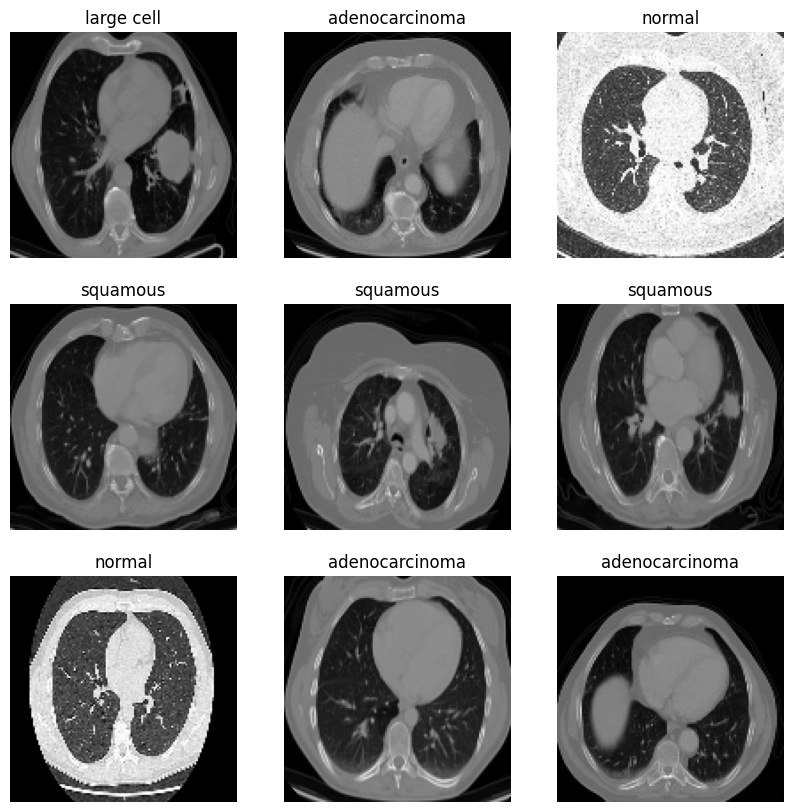

2026-04-29 19:19:58.665874: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
# navnene er veldig lange -> plottene ser dårlige ut# lager forkortelserdisplay_names = [    "adenocarcinoma",    "large cell",    "normal",    "squamous"]plt.figure(figsize=(10, 10))for images, labels in train_data.take(1):    for i in range(9):        plt.subplot(3, 3, i + 1)        plt.imshow(images[i].numpy())        plt.title(display_names[labels[i]])        plt.axis("off")    plt.show()

In [12]:
#14
def count_images_per_class(folder_path):
    counts = {}
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            counts[class_name] = len(os.listdir(class_folder))
    return counts

print("Train:", count_images_per_class(train_path))
print("Valid:", count_images_per_class(valid_path))
print("Test:", count_images_per_class(test_fixed_path))

Train: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 155, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 195, 'normal': 148, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 115}
Valid: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'normal': 13, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21}
Test: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 90, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 120, 'normal': 54, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 51}


In [13]:
def get_true_and_pred(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_labels = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(pred_labels)

    return np.array(y_true), np.array(y_pred)

In [14]:
def evaluate_model(model, dataset, model_name="Model", print_report=True):
    y_true, y_pred = get_true_and_pred(model, dataset)

    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    results = {
        "model": model_name,
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

    if print_report:
        print(f"evaluation for: {model_name}")
        print(json.dumps(results, indent=2))
        print(classification_report(y_true, y_pred, target_names=display_names, zero_division=0))

    return results, y_true, y_pred

In [15]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
    disp.plot(ax=ax, cmap="viridis", xticks_rotation=30, colorbar=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [16]:
def plot_history(history):
    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_acc, label="Train accuracy")
    plt.plot(epochs, val_acc, label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()

Modellering
--

Commonsense baseline
--

Vi ville ha en baseline-modell som vi kan prøve å forbedre med mer avanserte modeller. Vi bruker en majoritetsklasse-modell som alltid predikerer den mest vanlige klassen i treningssettet. I koden over kan vi se at adenocarcinoma er den største klassen i treningsdata. I koden under kan vi se at adenocarcinoma er i indeks 0, og vi kan bruke dette til å se hvilken accuracy vi får hvis vi kun tipper adenocarcinoma. Med denne "commonsense"-modellen får vi en baseline på omtrent 32% accuracy på validationsettet.

2026-04-29 19:19:58.840883: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Baseline validation accuracy: 0.3194444444444444
                precision    recall  f1-score   support

adenocarcinoma       0.32      1.00      0.48        23
    large cell       0.00      0.00      0.00        21
        normal       0.00      0.00      0.00        13
      squamous       0.00      0.00      0.00        15

      accuracy                           0.32        72
     macro avg       0.08      0.25      0.12        72
  weighted avg       0.10      0.32      0.15        72



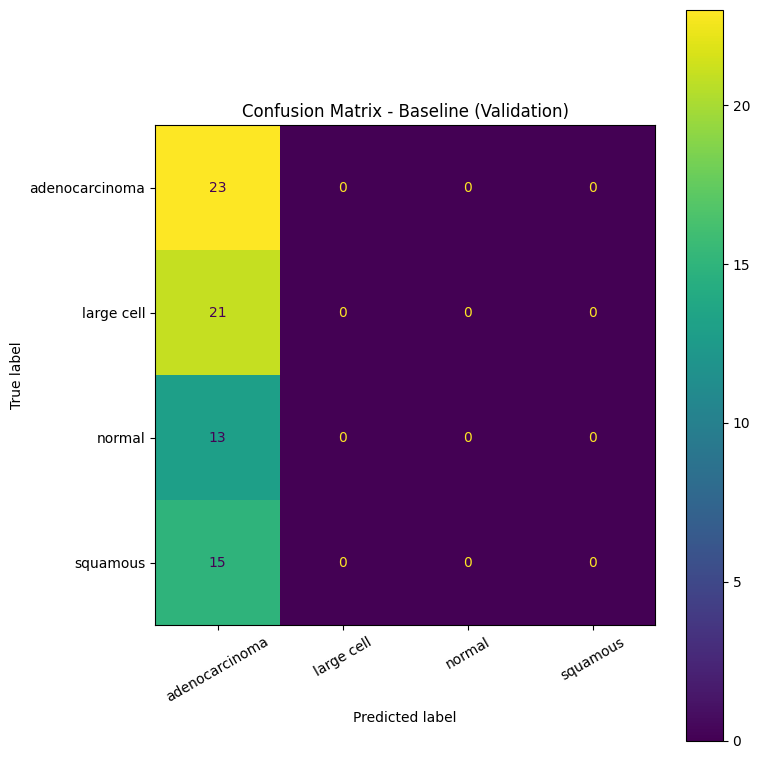

In [17]:
majority_class = 0

labels_true = []

for img, label in valid_data:
    labels_true.extend(label.numpy())

labels_true = np.array(labels_true)
labels_pred = np.full_like(labels_true, fill_value=majority_class)

print("Baseline validation accuracy:", accuracy_score(labels_true, labels_pred))
print(classification_report(labels_true, labels_pred, target_names=display_names, zero_division=0))
plot_confusion(labels_true, labels_pred, "Confusion Matrix - Baseline (Validation)")

Simple dens layer neural network
--

In [18]:
ff_network = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax")
])

ff_network.summary()

Model: "sequential"

Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€â€œ
Ã¢â€Æ’ Layer (type)                    Ã¢â€Æ’ Output Shape           Ã¢â€Æ’       Param # Ã¢â€Æ’
Ã¢â€Â¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â©
Ã¢â€â€š flatten (Flatten)               Ã¢â€â€š (None, 49152)          Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š dense (Dense)                   Ã¢â€â€š (None, 64)             Ã¢â€â€š     3,145,792 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š dense_1 (Dense)                 Ã¢â€â€š (None, 16)             Ã¢â€â€š         1,040 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š dense_2 (Dense)                 Ã¢â€â€š (None, 4)              Ã¢â€â€š            68 Ã¢â€â€š
Ã¢â€â€Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â´Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â´Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€

 Total params: 3,146,900 (12.00 MB)

 Trainable params: 3,146,900 (12.00 MB)

 Non-trainable params: 0 (0.00 B)

ff_network summary:--flatten: gjør vår input 128 * 128 * 3 om til en lang liste med tall = 49152.første dense laget: (input_features × neurons) + bias = 3,145,792andre dense laget: 64 * 16 + 16 = 1,040siste dense laget: 16 * 4 + 4 = 68

In [19]:
ff_network.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer="adam",
    metrics=["accuracy"]
)

In [20]:
history_ff = ff_network.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10


2026-04-29 19:19:59.201715: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 29ms/step - accuracy: 0.3703 - loss: 58.4124 - val_accuracy: 0.3194 - val_loss: 84.7268
Epoch 2/10
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 0s 20ms/step - accuracy: 0.4192 - loss: 32.6064 - val_accuracy: 0.3750 - val_loss: 30.9128
Epoch 3/10
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 0s 19ms/step - accuracy: 0.4698 - loss: 10.0839 - val_accuracy: 0.3611 - val_loss: 5.9810
Epoch 4/10
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 0s 19ms/step - accuracy: 0.5432 - loss: 4.3439 - val_accuracy: 0.3889 - val_loss: 3.4971
Epoch 5/10
20/20 Ã

In [21]:
score = ff_network.evaluate(valid_data, verbose=0)

print("loss:", score[0])
print("Accuracy of the model was {}%".format(score[1]*100))

loss: 2.7276902198791504
Accuracy of the model was 55.55555820465088%


evaluation for: FFNN - validation
{
  "model": "FFNN - validation",
  "accuracy": 0.5555555555555556,
  "precision_macro": 0.5678571428571428,
  "recall_macro": 0.5563306258958433,
  "f1_macro": 0.5480175864040535,
  "f1_weighted": 0.5488456457877408
}
                precision    recall  f1-score   support

adenocarcinoma       0.53      0.70      0.60        23
    large cell       0.67      0.38      0.48        21
        normal       0.50      0.62      0.55        13
      squamous       0.57      0.53      0.55        15

      accuracy                           0.56        72
     macro avg       0.57      0.56      0.55        72
  weighted avg       0.57      0.56      0.55        72



2026-04-29 19:20:04.212104: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


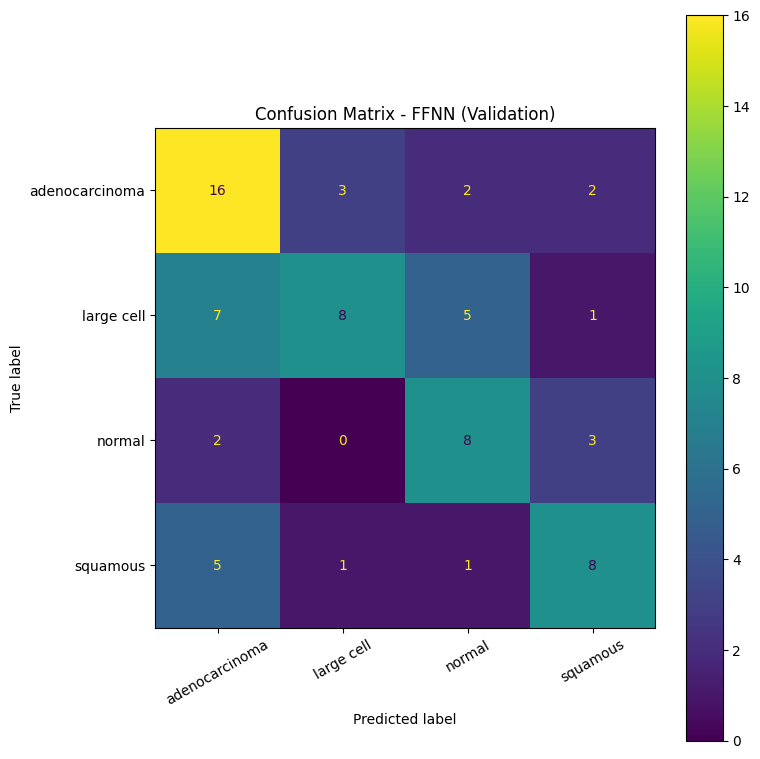

In [22]:
ff_results, y_true_ff, y_pred_ff = evaluate_model(
    ff_network,
    valid_data,
    model_name="FFNN - validation"
)

plot_confusion(y_true_ff, y_pred_ff, "Confusion Matrix - FFNN (Validation)")

Vi kan tydelig se at modellen vår ikke er god nok. Vi kan videre undersøke hvordan modellen fungerer.

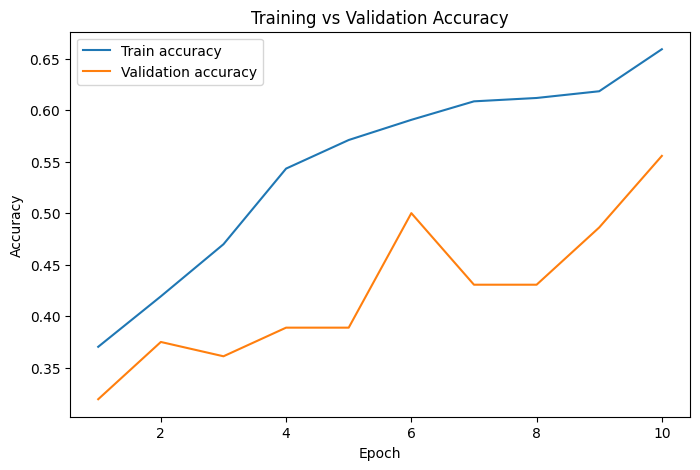

In [23]:
import matplotlib.pyplot as plt

train_acc = history_ff.history["accuracy"]
val_acc = history_ff.history["val_accuracy"]
train_loss = history_ff.history["loss"]
val_loss = history_ff.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

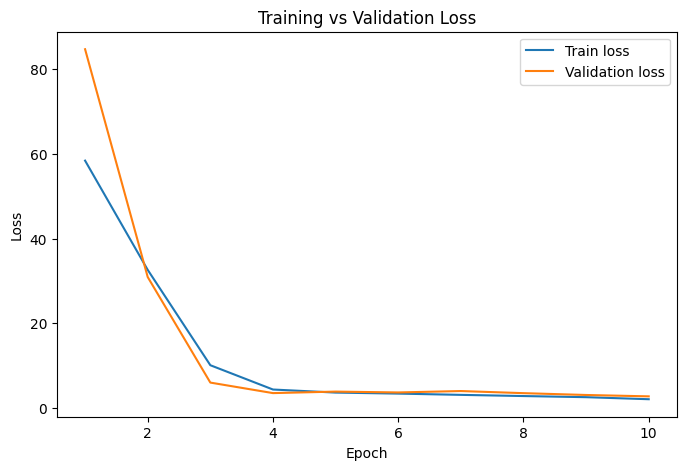

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Tolkning av graf og confusion matrix--Treningsaccuracy øker jevnt gjennom treningen, noe som indikerer at modellen lærer mønstre i dataene. Validation accuracy vokser på lik måte, men holder seg noe under treningsdataene gjennom hele treningsfasen, noe som kan tyde på svak overfitting.Både trening- og validation loss synker kraftig i starten, noe som tyder på effektiv trening.Confusion matrixen viser at modellen gjør det bra på adenocarcinoma. Matrisen viser at modellen sliter spesielt med å predikere large cell, hvor omtrent 2/3 av modellens prediksjoner av large cell var feil. Dette kan tyde på at modellen sliter med å skille large cell fra de andre klassene. Vi kan prøve å forbedre dette med data augmentation.

In [25]:
print("Train:", count_images_per_class(train_path))
print("Valid:", count_images_per_class(valid_path))
print("Test:", count_images_per_class(test_path))

Train: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 155, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 195, 'normal': 148, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 115}
Valid: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'normal': 13, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21}
Test: {'squamous.cell.carcinoma': 90, 'large.cell.carcinoma': 51, 'adenocarcinoma': 120, 'normal': 54}


Vi kan tydelig se at large cell er den klassen med minst treningssamples. Dette kan forklare hvorfor modellen ikke klarer å lære gode mønstre for denne klassen.Samtidig ser vi at testsettet inneholder 120 tilfeller av adenocarcinoma, men modellen klarer kun å klassifisere 8 riktig. Dette kan tyde på at datasettet ikke er det eneste problemet, men at modellen ikke klarer å fange opp mønstre i dataene. Dette er forventet i en feedforward-modell som ser bilder som en flattenet liste med tall.

Data augmentation and rescaling--Vi kan prøve å fikse problemet med lite data ved hjelp av augmentation:

In [26]:
data_augmentation_ff = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.02),
    tf.keras.layers.RandomZoom(0.2)
])

ff_network_aug = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    data_augmentation_ff,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax")
])

ff_network_aug.summary()

Model: "sequential_2"

Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€â€œ
Ã¢â€Æ’ Layer (type)                    Ã¢â€Æ’ Output Shape           Ã¢â€Æ’       Param # Ã¢â€Æ’
Ã¢â€Â¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â©
Ã¢â€â€š sequential_1 (Sequential)       Ã¢â€â€š (None, 128, 128, 3)    Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š flatten_1 (Flatten)             Ã¢â€â€š (None, 49152)          Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š dense_3 (Dense)                 Ã¢â€â€š (None, 64)             Ã¢â€â€š     3,145,792 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š dropout (Dropout)               Ã¢â€â€š (None, 64)             Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â

 Total params: 3,146,900 (12.00 MB)

 Trainable params: 3,146,900 (12.00 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
ff_network_aug.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer="adam",
    metrics=["accuracy"]
)

In [28]:
history_ff_aug = ff_network_aug.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 2s 41ms/step - accuracy: 0.2594 - loss: 57.7445 - val_accuracy: 0.3472 - val_loss: 26.7689
Epoch 2/10
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 31ms/step - accuracy: 0.2529 - loss: 80.6961 - val_accuracy: 0.3611 - val_loss: 21.0178
Epoch 3/10
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 31ms/step - accuracy: 0.2773 - loss: 81.0841 - val_accuracy: 0.3889 - val_loss: 36.7088
Epoch 4/10
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 32ms/step - accuracy: 0.2822 - loss: 77.2620 - val_accuracy: 0.4306 - val_loss: 30.7534
Epoc

In [29]:
score = ff_network_aug.evaluate(valid_data, verbose=0)

print("Valid loss:", score[0])
print("Valid accuracy:", score[1])

Valid loss: 20.843358993530273
Valid accuracy: 0.4166666567325592


evaluation for: FFNN + augmentation - validation
{
  "model": "FFNN + augmentation - validation",
  "accuracy": 0.4166666666666667,
  "precision_macro": 0.33984375,
  "recall_macro": 0.3846153846153846,
  "f1_macro": 0.307183908045977,
  "f1_weighted": 0.29529054916985953
}
                precision    recall  f1-score   support

adenocarcinoma       0.36      1.00      0.53        23
    large cell       0.00      0.00      0.00        21
        normal       1.00      0.54      0.70        13
      squamous       0.00      0.00      0.00        15

      accuracy                           0.42        72
     macro avg       0.34      0.38      0.31        72
  weighted avg       0.30      0.42      0.30        72



2026-04-29 19:20:12.263879: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


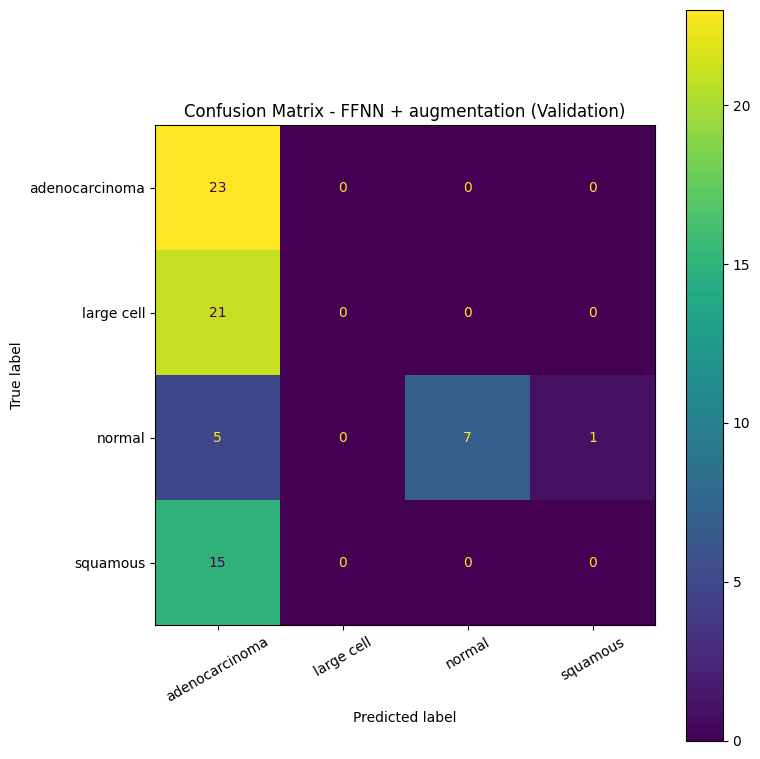

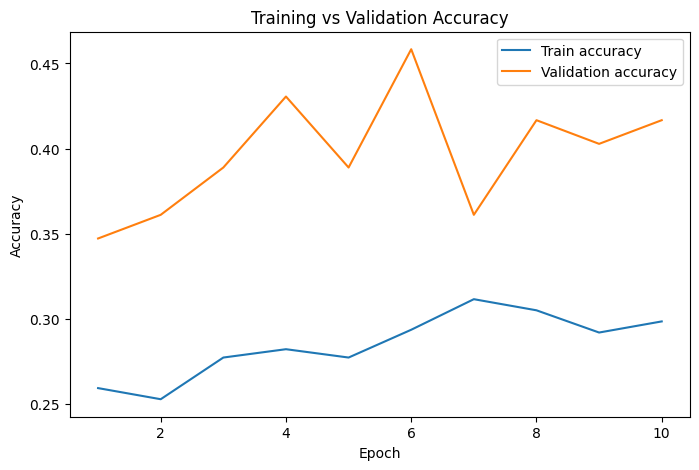

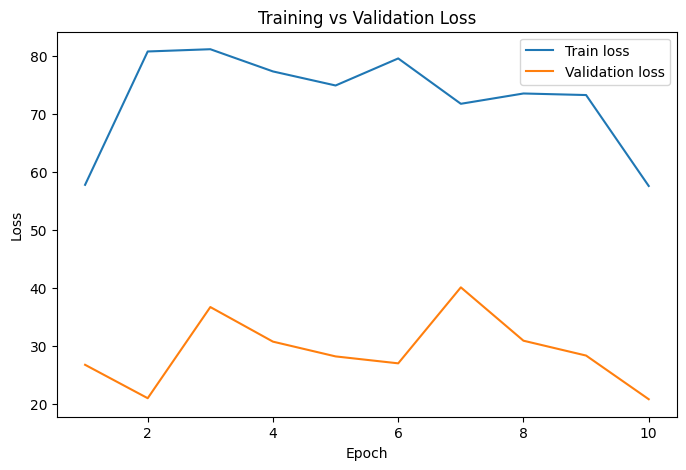

In [30]:
ff_aug_results, y_true_ff_aug, y_pred_ff_aug = evaluate_model(
    ff_network_aug,
    valid_data,
    model_name="FFNN + augmentation - validation"
)

plot_confusion(y_true_ff_aug, y_pred_ff_aug, "Confusion Matrix - FFNN + augmentation (Validation)")
plot_history(history_ff_aug)

Konklusjon av FFNN:--Confusion matrixen viser en stor bias i modellen, hvor nesten alle blir klassifisert som adenocarcinoma. Selv om recall er perfekt for denne klassen, feiler modellen fullstendig på å klassifisere large cell og squamous, hvor begge har null i recall.Grafene viser at både trenings- og valideringsaccuracy holder seg lav gjennom alle epokene, noe som viser at modellen ikke greier å fange mønstre i dataene.Med omfattende testing og analyse ser vi at resultatene fra FFNN-modellen ikke er pålitelige nok til å trekke en konklusjon. Modellen er for enkel, og datasettet er for lite til at modellen kan lære gode mønstre. Vi observerte også stor variasjon (+- 15%) mellom kjøring av samme kode med forskjellige seed, noe som tyder på at en mer avansert modell må tas i bruk.

Prøver CNN-modell--

In [31]:
#model3
simple_cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(4, activation="softmax")
])

In [32]:
simple_cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

simple_cnn_model.summary()

Model: "sequential_3"

Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€â€œ
Ã¢â€Æ’ Layer (type)                    Ã¢â€Æ’ Output Shape           Ã¢â€Æ’       Param # Ã¢â€Æ’
Ã¢â€Â¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â©
Ã¢â€â€š conv2d (Conv2D)                 Ã¢â€â€š (None, 126, 126, 32)   Ã¢â€â€š           896 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š max_pooling2d (MaxPooling2D)    Ã¢â€â€š (None, 63, 63, 32)     Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š conv2d_1 (Conv2D)               Ã¢â€â€š (None, 61, 61, 64)     Ã¢â€â€š        18,496 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š max_pooling2d_1 (MaxPooling2D)  Ã¢â€â€š (None, 30, 30, 64)     Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â

 Total params: 101,764 (397.52 KB)

 Trainable params: 101,764 (397.52 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history_simple_cnn = simple_cnn_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=15,
)

Epoch 1/15
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 2s 44ms/step - accuracy: 0.3018 - loss: 1.3528 - val_accuracy: 0.1806 - val_loss: 1.3647
Epoch 2/15
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 33ms/step - accuracy: 0.3670 - loss: 1.2425 - val_accuracy: 0.3056 - val_loss: 1.2661
Epoch 3/15
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 32ms/step - accuracy: 0.4584 - loss: 1.1540 - val_accuracy: 0.5000 - val_loss: 1.1121
Epoch 4/15
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 31ms/step - accuracy: 0.4959 - loss: 1.0787 - val_accuracy: 0.5000 - val_loss: 1.1202
Epoch 5/15
2

In [34]:
#50
valid_loss, valid_acc = simple_cnn_model.evaluate(valid_data, verbose=0)

print("Validation loss:", valid_loss)
print("Validation accuracy:", valid_acc)

Validation loss: 0.9776577353477478
Validation accuracy: 0.4722222089767456


evaluation for: CNN from scratch - validation
{
  "model": "CNN from scratch - validation",
  "accuracy": 0.4722222222222222,
  "precision_macro": 0.4082446808510638,
  "recall_macro": 0.49565217391304345,
  "f1_macro": 0.43412698412698414,
  "f1_weighted": 0.3911375661375661
}
                precision    recall  f1-score   support

adenocarcinoma       0.38      0.78      0.51        23
    large cell       0.00      0.00      0.00        21
        normal       1.00      1.00      1.00        13
      squamous       0.25      0.20      0.22        15

      accuracy                           0.47        72
     macro avg       0.41      0.50      0.43        72
  weighted avg       0.35      0.47      0.39        72



2026-04-29 19:20:24.278489: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


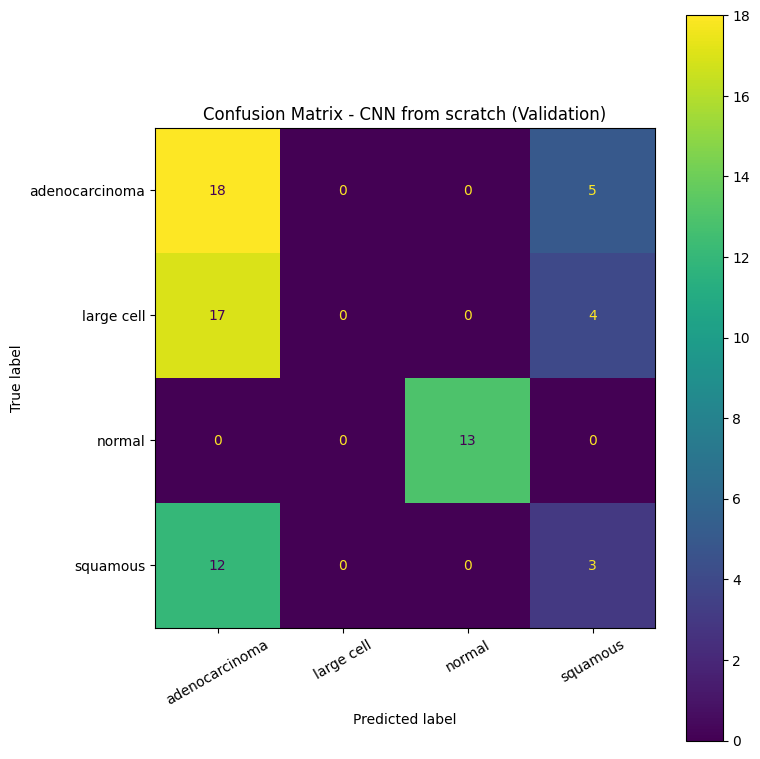

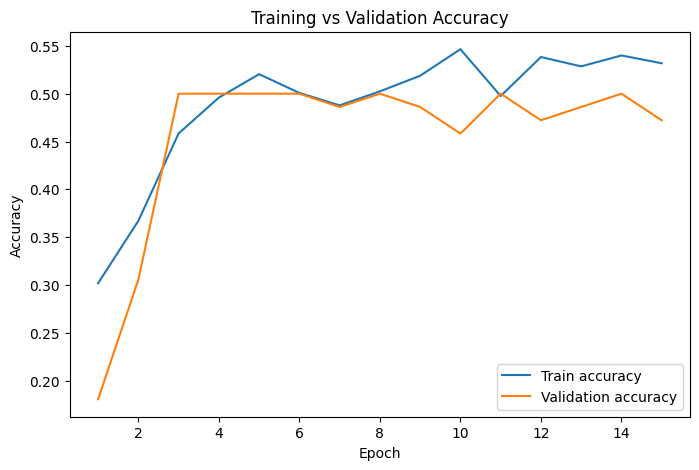

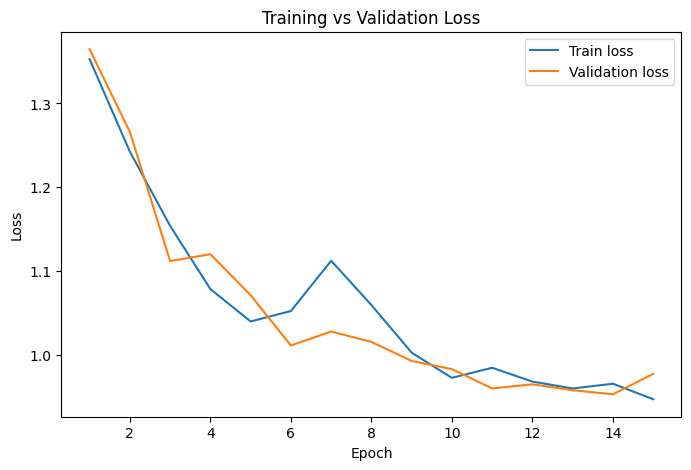

In [35]:
simple_cnn_results, y_true_simple_cnn, y_pred_simple_cnn = evaluate_model(
    simple_cnn_model,
    valid_data,
    model_name="CNN from scratch - validation"
)

plot_confusion(y_true_simple_cnn, y_pred_simple_cnn, "Confusion Matrix - CNN from scratch (Validation)")
plot_history(history_simple_cnn)

Tolkning--Confusion matrixen viser at modellen gjør det veldig bra på normal-klassen, hvor recall var 100%, men modellen sliter fortsatt veldig med å skille mellom de forskjellige krefttypene, spesielt large cell og squamous. Dette viser at modellen klarer å skille mellom syke og ikke-syke, men feiler på å skille mellom de forskjellige krefttypene.Både trenings- og valideringsaccuracy vokser over epokene og holder seg relativt nær hverandre, noe som kan tyde på svak overfitting og gir mulighet for å lage en mer kompleks maskinlæringsmodell med eventuelt flere lag eller epoker.Trenings- og valideringsloss synker fort, noe som tyder på at modellen lærer mønstre i dataene.Prøver en mer kompleks CNN-modell:

In [36]:
larger_cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(4, activation="softmax")
])

In [37]:
larger_cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

larger_cnn_model.summary()

history_larger_cnn = larger_cnn_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20
)

valid_loss, valid_acc = larger_cnn_model.evaluate(valid_data, verbose=0)

print("Validation loss:", valid_loss)
print("Validation accuracy:", valid_acc)

Model: "sequential_4"

Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€â€œ
Ã¢â€Æ’ Layer (type)                    Ã¢â€Æ’ Output Shape           Ã¢â€Æ’       Param # Ã¢â€Æ’
Ã¢â€Â¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â©
Ã¢â€â€š conv2d_3 (Conv2D)               Ã¢â€â€š (None, 126, 126, 64)   Ã¢â€â€š         1,792 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š max_pooling2d_3 (MaxPooling2D)  Ã¢â€â€š (None, 63, 63, 64)     Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š conv2d_4 (Conv2D)               Ã¢â€â€š (None, 61, 61, 128)    Ã¢â€â€š        73,856 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š max_pooling2d_4 (MaxPooling2D)  Ã¢â€â€š (None, 30, 30, 128)    Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â

 Total params: 404,228 (1.54 MB)

 Trainable params: 404,228 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 2s 70ms/step - accuracy: 0.2741 - loss: 1.3438 - val_accuracy: 0.2083 - val_loss: 1.3062
Epoch 2/20
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 56ms/step - accuracy: 0.4274 - loss: 1.1953 - val_accuracy: 0.5000 - val_loss: 1.1525
Epoch 3/20
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 56ms/step - accuracy: 0.4747 - loss: 1.1161 - val_accuracy: 0.4861 - val_loss: 1.0804
Epoch 4/20
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 57ms/step - accuracy: 0.5139 - loss: 1.0745 - val_accuracy: 0.5000 - val_loss: 1.0872
Epoch 5/20
2

evaluation for: Larger CNN - validation
{
  "model": "Larger CNN - validation",
  "accuracy": 0.5277777777777778,
  "precision_macro": 0.6200731981981982,
  "recall_macro": 0.5443064182194617,
  "f1_macro": 0.5326463560334528,
  "f1_weighted": 0.50992134607726
}
                precision    recall  f1-score   support

adenocarcinoma       0.46      0.74      0.57        23
    large cell       0.83      0.24      0.37        21
        normal       1.00      1.00      1.00        13
      squamous       0.19      0.20      0.19        15

      accuracy                           0.53        72
     macro avg       0.62      0.54      0.53        72
  weighted avg       0.61      0.53      0.51        72



2026-04-29 19:20:49.383586: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


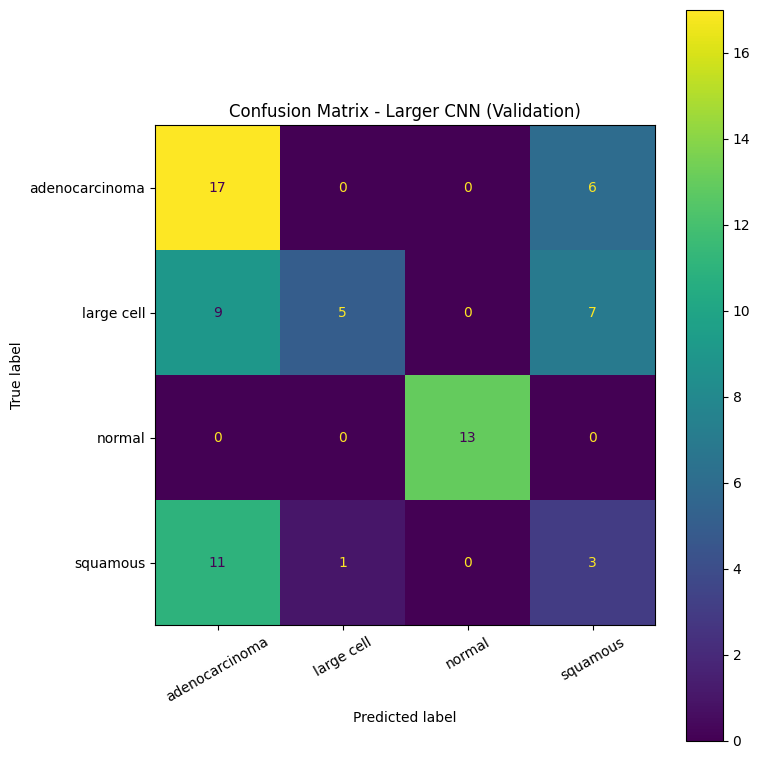

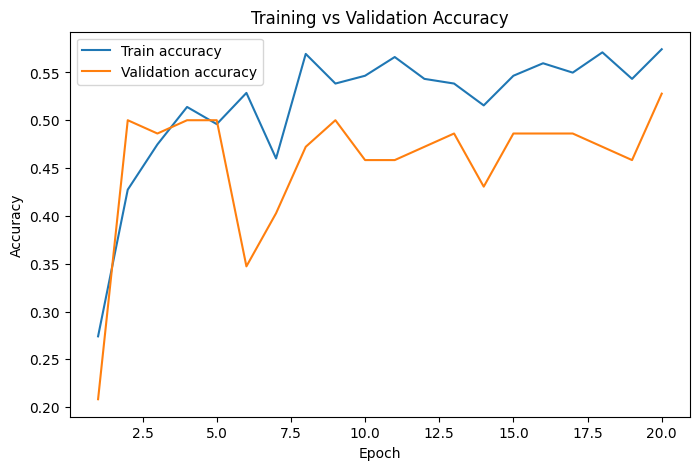

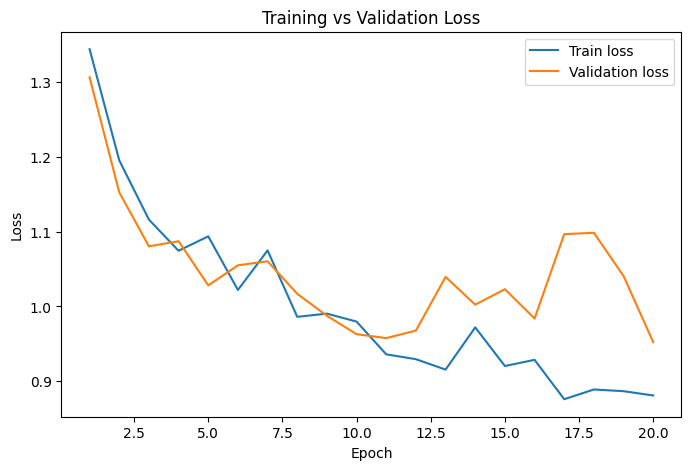

In [38]:
larger_cnn_results, y_true_larger_cnn, y_pred_larger_cnn = evaluate_model(
    larger_cnn_model,
    valid_data,
    model_name="Larger CNN - validation"
)

plot_confusion(y_true_larger_cnn, y_pred_larger_cnn, "Confusion Matrix - Larger CNN (Validation)")
plot_history(history_larger_cnn)

Tolkning av graf--Denne CNN-modellen gjør det bedre enn den vi lagde tidligere, spesielt når det kommer til large cell. Den tidligere CNN-modellen hadde null prediksjoner mot large cell, mens denne modellen hadde 6 prediksjoner, hvor 5 av dem var riktig predikert. Vi kan se at modellen fortsatt sliter med å skille mellom de ulike krefttypene, hvor mesteparten av prediksjonene var adenocarcinoma. Modellen klarer fortsatt å få full score på normal-klassen.Vi kan prøve å lage en forbedret modell med data augmentation og early stopping for å se om det gjør en forskjell.

In [39]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomZoom(0.1),
])

improved_cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation="softmax")
])

In [40]:
improved_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history_improved_cnn = improved_cnn_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=25,
    callbacks=[early_stopping]
)

improved_cnn_model.summary()

valid_loss, valid_acc = improved_cnn_model.evaluate(valid_data, verbose=0)

print("Validation loss:", valid_loss)
print("Validation accuracy:", valid_acc)

Epoch 1/25
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 2s 54ms/step - accuracy: 0.2985 - loss: 1.3492 - val_accuracy: 0.1806 - val_loss: 1.4777
Epoch 2/25
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 40ms/step - accuracy: 0.3197 - loss: 1.3286 - val_accuracy: 0.1806 - val_loss: 1.4425
Epoch 3/25
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 39ms/step - accuracy: 0.3556 - loss: 1.2710 - val_accuracy: 0.1944 - val_loss: 1.5151
Epoch 4/25
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 40ms/step - accuracy: 0.4731 - loss: 1.2009 - val_accuracy: 0.4861 - val_loss: 1.1732
Epoch 5/25
2

Model: "sequential_6"

Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€â€œ
Ã¢â€Æ’ Layer (type)                    Ã¢â€Æ’ Output Shape           Ã¢â€Æ’       Param # Ã¢â€Æ’
Ã¢â€Â¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â©
Ã¢â€â€š sequential_5 (Sequential)       Ã¢â€â€š (None, 128, 128, 3)    Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š conv2d_6 (Conv2D)               Ã¢â€â€š (None, 128, 128, 32)   Ã¢â€â€š           896 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š max_pooling2d_6 (MaxPooling2D)  Ã¢â€â€š (None, 64, 64, 32)     Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š conv2d_7 (Conv2D)               Ã¢â€â€š (None, 64, 64, 64)     Ã¢â€â€š        18,496 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â

 Total params: 305,294 (1.16 MB)

 Trainable params: 101,764 (397.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,530 (795.04 KB)

Validation loss: 0.9588253498077393
Validation accuracy: 0.5


evaluation for: Improved CNN - validation
{
  "model": "Improved CNN - validation",
  "accuracy": 0.5,
  "precision_macro": 0.4532967032967033,
  "recall_macro": 0.5173913043478261,
  "f1_macro": 0.4515151515151515,
  "f1_weighted": 0.40774410774410774
}
                precision    recall  f1-score   support

adenocarcinoma       0.38      0.87      0.53        23
    large cell       0.00      0.00      0.00        21
        normal       1.00      1.00      1.00        13
      squamous       0.43      0.20      0.27        15

      accuracy                           0.50        72
     macro avg       0.45      0.52      0.45        72
  weighted avg       0.39      0.50      0.41        72



2026-04-29 19:21:07.081503: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


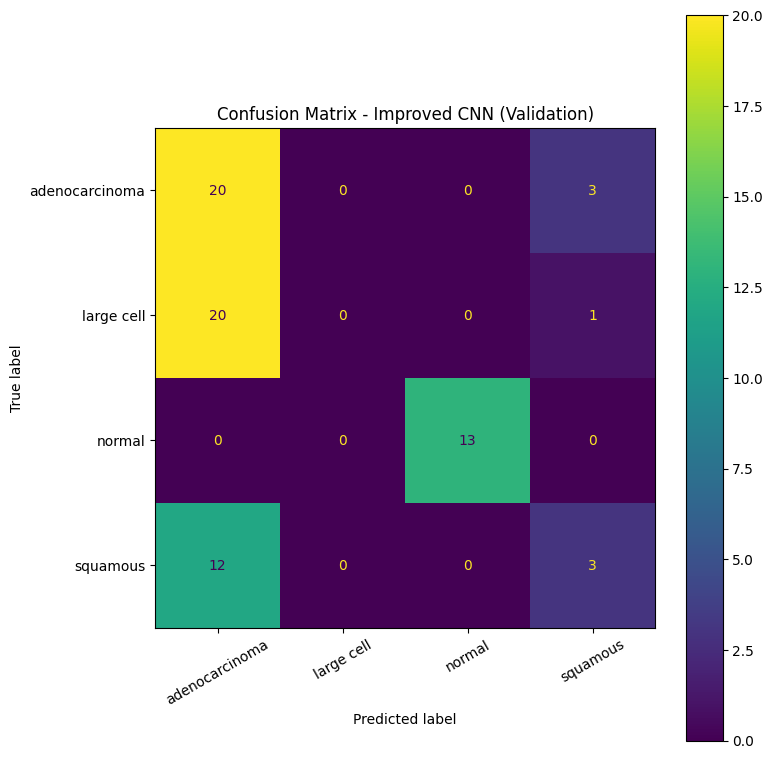

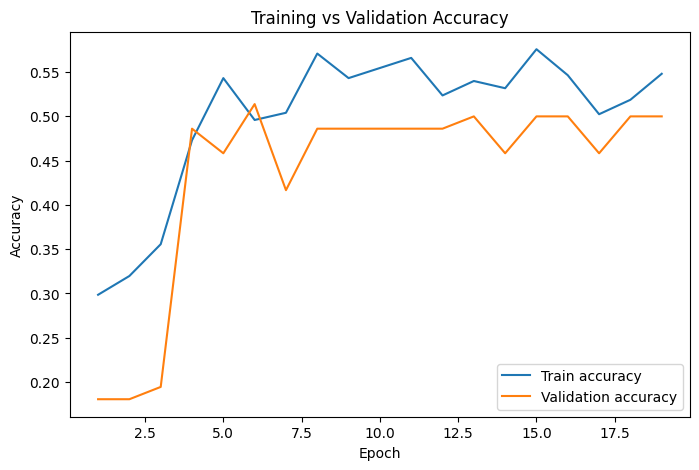

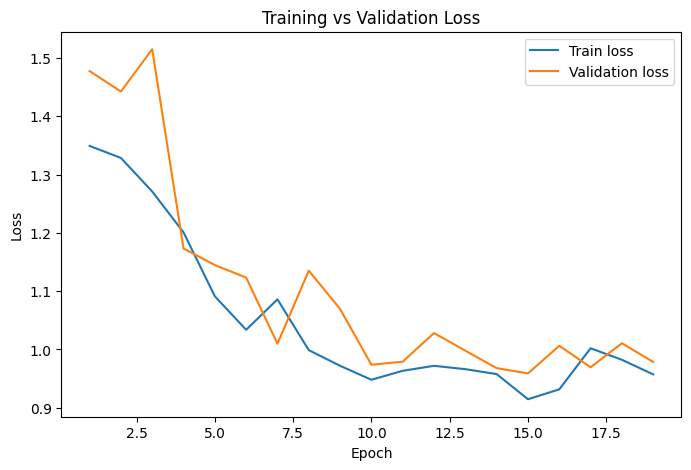

In [41]:
improved_cnn_results, y_true_improved_cnn, y_pred_improved_cnn = evaluate_model(
    improved_cnn_model,
    valid_data,
    model_name="Improved CNN - validation"
)

plot_confusion(y_true_improved_cnn, y_pred_improved_cnn, "Confusion Matrix - Improved CNN (Validation)")
plot_history(history_improved_cnn)

Tolkning av confusion matrix--Confusion matrixen viser fortsatt en tydelig skjevhet i prediksjonene, hvor nesten alle tilfellene klassifiseres som adenocarcinoma. Dette fører til at klasser som large cell og squamous nesten aldri blir riktig klassifisert. Modellene klarer ikke å fange gode nok mønstre for alle klassene i datasettet.På grunn av lite datasett kan vi se om transfer learning kan løse problemet. Transfer learning trenger ikke like mye data som andre modeller for å oppnå høy accuracy.

Transfer learning--(Denne prosessen med transfer learning har blitt gjort med hjelp av ChatGPT, for å sikre et smart valg av modell og riktig oppsett)

In [42]:
mobilenet_preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess_for_mobilenet(ds):
    ds = ds.map(
        lambda x, y: (mobilenet_preprocess(x), y),
        num_parallel_calls=AUTOTUNE
    )
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_tl = preprocess_for_mobilenet(train_raw)
valid_tl = preprocess_for_mobilenet(valid_raw)
test_tl = preprocess_for_mobilenet(test_raw)

In [43]:
data_augmentation_tl = tf.keras.Sequential([
    tf.keras.layers.RandomZoom(0.1)
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

pretrained_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    data_augmentation_tl,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation="softmax")
])

pretrained_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pretrained_model.summary()

Model: "sequential_8"

Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€â€œ
Ã¢â€Æ’ Layer (type)                    Ã¢â€Æ’ Output Shape           Ã¢â€Æ’       Param # Ã¢â€Æ’
Ã¢â€Â¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â©
Ã¢â€â€š sequential_7 (Sequential)       Ã¢â€â€š (None, 128, 128, 3)    Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š mobilenetv2_1.00_128            Ã¢â€â€š (None, 4, 4, 1280)     Ã¢â€â€š     2,257,984 Ã¢â€â€š
Ã¢â€â€š (Functional)                    Ã¢â€â€š                        Ã¢â€â€š               Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š global_average_pooling2d_3      Ã¢â€â€š (None, 1280)           Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€â€š (GlobalAveragePooling2D)        Ã¢â€â€š                        Ã¢â€â€š               Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š dense_12 (Dense)                Ã¢â€â€š (None, 64)             Ã¢â€â€š        81,984 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â

 Total params: 2,340,228 (8.93 MB)

 Trainable params: 82,244 (321.27 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [44]:
history_pretrained = pretrained_model.fit(
    train_tl,
    validation_data=valid_tl,
    epochs=20
)

Epoch 1/20
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 6s 180ms/step - accuracy: 0.4241 - loss: 1.7688 - val_accuracy: 0.5417 - val_loss: 1.1559
Epoch 2/20
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 47ms/step - accuracy: 0.5383 - loss: 1.4877 - val_accuracy: 0.5833 - val_loss: 1.3040
Epoch 3/20
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 47ms/step - accuracy: 0.5873 - loss: 1.3699 - val_accuracy: 0.5417 - val_loss: 1.4091
Epoch 4/20
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 1s 45ms/step - accuracy: 0.6378 - loss: 1.1758 - val_accuracy: 0.5278 - val_loss: 1.4814
Epoch 5/20


Validation loss: 1.2318406105041504
Validation accuracy: 0.6527777910232544
evaluation for: Transfer learning (frozen base) - validation
{
  "model": "Transfer learning (frozen base) - validation",
  "accuracy": 0.6527777777777778,
  "precision_macro": 0.728006993006993,
  "recall_macro": 0.667566491479535,
  "f1_macro": 0.668985692102928,
  "f1_weighted": 0.6573059930493937
}
                precision    recall  f1-score   support

adenocarcinoma       0.65      0.74      0.69        23
    large cell       0.82      0.43      0.56        21
        normal       1.00      0.77      0.87        13
      squamous       0.44      0.73      0.55        15

      accuracy                           0.65        72
     macro avg       0.73      0.67      0.67        72
  weighted avg       0.72      0.65      0.66        72



2026-04-29 19:21:36.150593: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


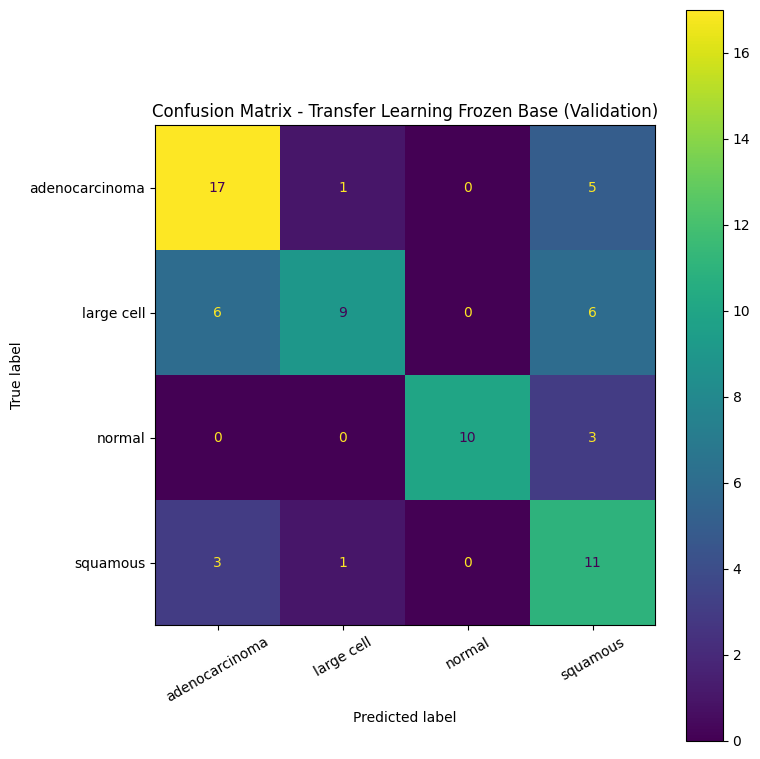

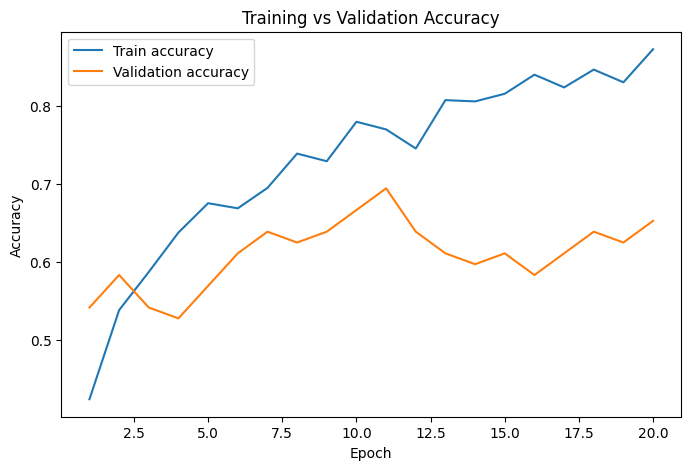

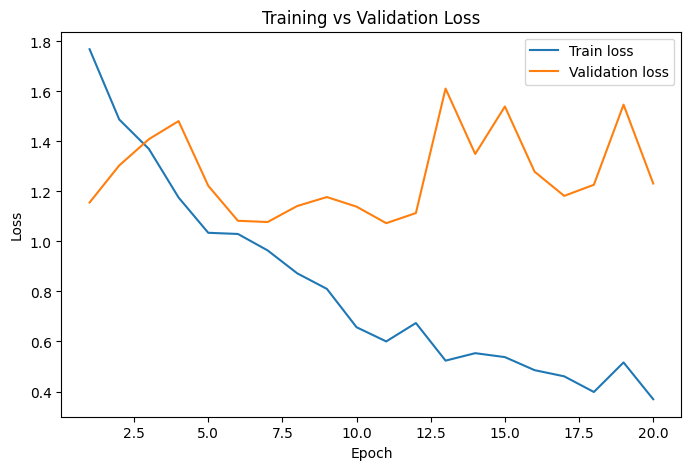

In [45]:
score = pretrained_model.evaluate(valid_tl, verbose=0)
print("Validation loss:", score[0])
print("Validation accuracy:", score[1])

pretrained_results, y_true_pretrained, y_pred_pretrained = evaluate_model(
    pretrained_model,
    valid_tl,
    model_name="Transfer learning (frozen base) - validation"
)

plot_confusion(
    y_true_pretrained,
    y_pred_pretrained,
    "Confusion Matrix - Transfer Learning Frozen Base (Validation)"
)

plot_history(history_pretrained)

Tolkning av graf--Transfer learning-modellen viser en stor forbedring i balansen mellom alle klassene. I motsetning til før klarer modellen å predikere alle klassene til en viss grad. Spesielt har prediksjonen av large cell og squamous økt veldig. Treningsloss synker fint gjennom alle epokene, men valideringsloss begynner å hoppe litt fra epoke 12, noe som kan tyde på at modellen begynner å overfitte.

In [46]:
frozen_model = tf.keras.models.clone_model(pretrained_model)

frozen_model.set_weights(pretrained_model.get_weights())

frozen_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]

)

frozen_model.save("frozen_model.keras")

In [47]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

pretrained_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [48]:
history_pretrained_finetuned = pretrained_model.fit(
    train_tl,
    validation_data=valid_tl,
    epochs=10
)

Epoch 1/10
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 13s 332ms/step - accuracy: 0.5041 - loss: 2.3136 - val_accuracy: 0.6389 - val_loss: 1.3554
Epoch 2/10
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 2s 102ms/step - accuracy: 0.5628 - loss: 1.8884 - val_accuracy: 0.6389 - val_loss: 1.4701
Epoch 3/10
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 2s 91ms/step - accuracy: 0.6493 - loss: 1.4275 - val_accuracy: 0.6250 - val_loss: 1.5633
Epoch 4/10
20/20 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 2s 91ms/step - accuracy: 0.6884 - loss: 1.2412 - val_accuracy: 0.6111 - val_loss: 1.6118
Epoch 5/1

evaluation for: Transfer learning (fine-tuned) - validation
{
  "model": "Transfer learning (fine-tuned) - validation",
  "accuracy": 0.5972222222222222,
  "precision_macro": 0.7210791925465838,
  "recall_macro": 0.6267797419971333,
  "f1_macro": 0.6152372142196378,
  "f1_weighted": 0.5967211429746119
}
                precision    recall  f1-score   support

adenocarcinoma       0.65      0.65      0.65        23
    large cell       0.86      0.29      0.43        21
        normal       1.00      0.77      0.87        13
      squamous       0.38      0.80      0.51        15

      accuracy                           0.60        72
     macro avg       0.72      0.63      0.62        72
  weighted avg       0.72      0.60      0.60        72



2026-04-29 19:22:12.865684: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


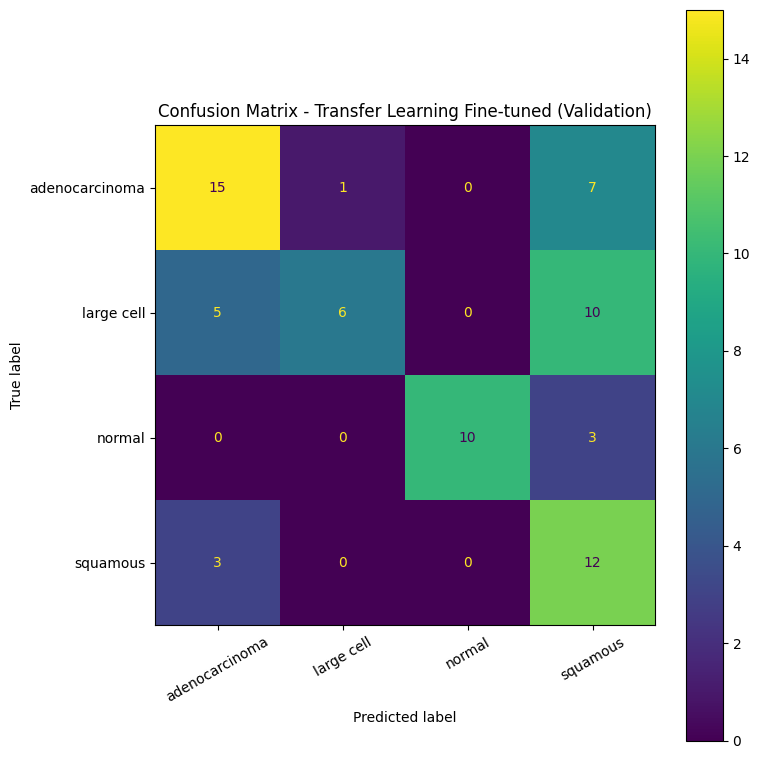

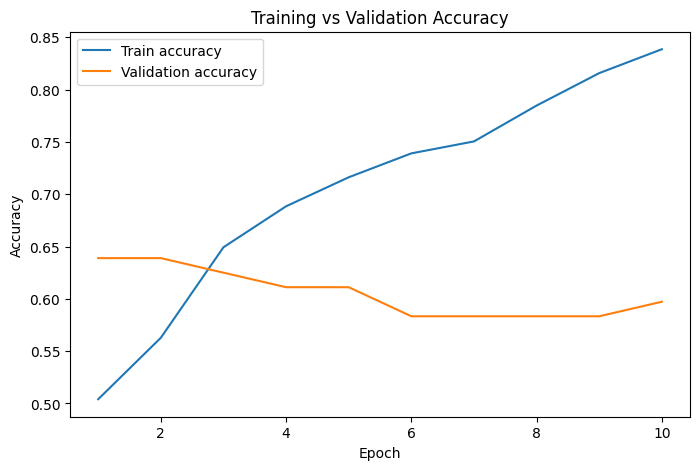

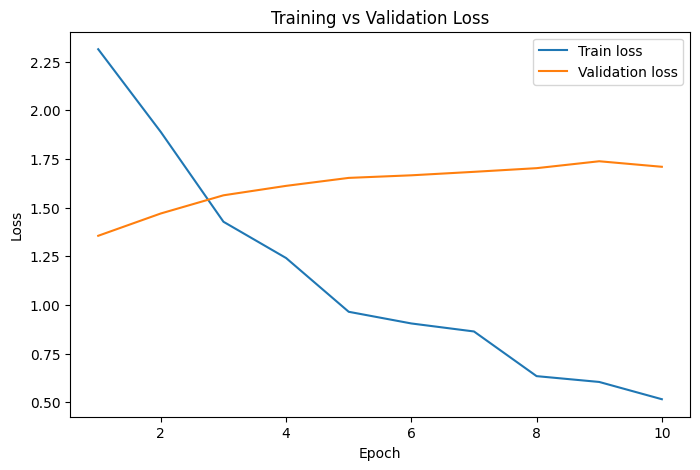

In [49]:
pretrained_finetuned_results, y_true_pretrained_ft, y_pred_pretrained_ft = evaluate_model(
    pretrained_model,
    valid_tl,
    model_name="Transfer learning (fine-tuned) - validation"
)

plot_confusion(
    y_true_pretrained_ft,
    y_pred_pretrained_ft,
    "Confusion Matrix - Transfer Learning Fine-tuned (Validation)"
)

plot_history(history_pretrained_finetuned)

Tolkning av graf--Fine-tuned transfer learning-modellen viser en endring i oppførsel når det kommer til valg av klasser sammenlignet med frozen transfer-modellen. Modellen gjør det litt bedre på squamous, men spesielt feilklassifisering av adenocarcinoma og large cell carcinoma som squamous økte.Treningsloss gikk ned over tid, mens valideringsloss økte litt over tid. Dette er et klart tegn på overfitting. Vi kan se det samme for accuracy, hvor treningsaccuracy økte stabilt mens valideringsaccuracy gikk ned. Dette fører til at modellen memoriserer treningsdata i stedet for å lære mønstre, noe som gjør den dårligere til å generalisere nye data.

In [50]:
import pandas as pd
results_df = pd.DataFrame([
    ff_results,
    ff_aug_results,
    simple_cnn_results,
    larger_cnn_results,
    improved_cnn_results,
    pretrained_results,
    pretrained_finetuned_results
])

results_df = results_df.sort_values(
    by="f1_macro",
    ascending=False
).reset_index(drop=True)

results_df

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Transfer learning (frozen base) - validation,0.652778,0.728007,0.667566,0.668986,0.657306
1,Transfer learning (fine-tuned) - validation,0.597222,0.721079,0.626780,0.615237,0.596721
2,FFNN - validation,0.555556,0.567857,0.556331,0.548018,0.548846
3,Larger CNN - validation,0.527778,0.620073,0.544306,0.532646,0.509921
4,Improved CNN - validation,0.500000,0.453297,0.517391,0.451515,0.407744
5,CNN from scratch - validation,0.472222,0.408245,0.495652,0.434127,0.391138
6,FFNN + augmentation - validation,0.416667,0.339844,0.384615,0.307184,0.295291


In [51]:
final_model = frozen_model
final_test_data = test_tl

evaluation for: Final model - test
{
  "model": "Final model - test",
  "accuracy": 0.7111111111111111,
  "precision_macro": 0.7336731705118962,
  "recall_macro": 0.7473856209150327,
  "f1_macro": 0.7328796484835495,
  "f1_weighted": 0.7144604518476557
}
                precision    recall  f1-score   support

adenocarcinoma       0.76      0.60      0.67       120
    large cell       0.52      0.75      0.61        51
        normal       1.00      0.94      0.97        54
      squamous       0.66      0.70      0.68        90

      accuracy                           0.71       315
     macro avg       0.73      0.75      0.73       315
  weighted avg       0.73      0.71      0.71       315



2026-04-29 19:22:18.080165: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


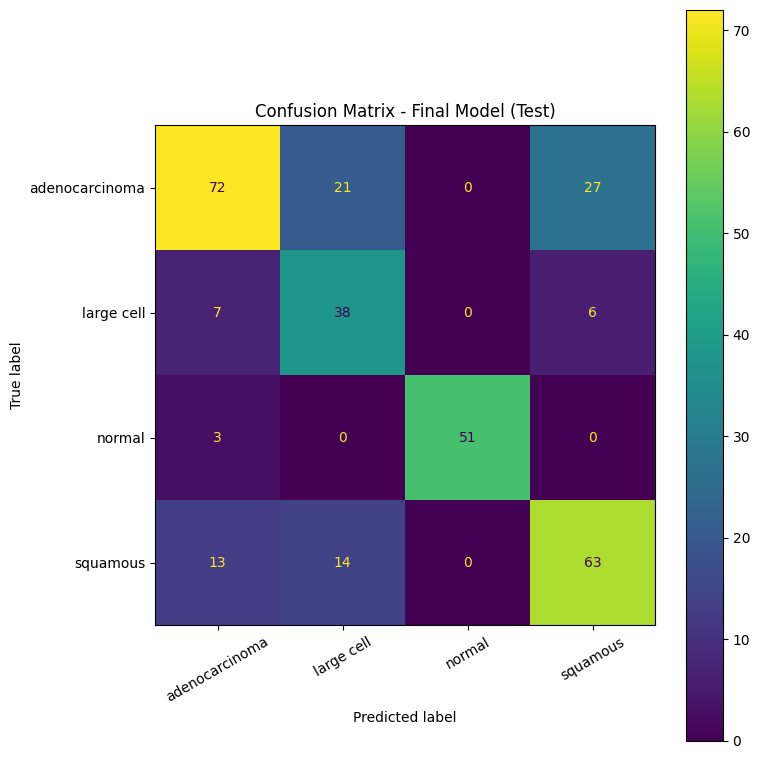

In [52]:
final_results, y_true_test, y_pred_test = evaluate_model(
    final_model,
    final_test_data,
    model_name="Final model - test"
)

plot_confusion(
    y_true_test,
    y_pred_test,
    "Confusion Matrix - Final Model (Test)"
)

In [53]:
def show_misclassified_images(model, dataset, class_names, num_images=12):
    misclassified_images = []
    true_labels = []
    predicted_labels = []
    confidences = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        preds = np.argmax(predictions, axis=1)
        confs = np.max(predictions, axis=1)

        for i in range(len(labels)):
            if preds[i] != labels[i].numpy():
                misclassified_images.append(images[i].numpy())
                true_labels.append(labels[i].numpy())
                predicted_labels.append(preds[i])
                confidences.append(confs[i])

    num_images = min(num_images, len(misclassified_images))

    plt.figure(figsize=(15, 10))

    for i in range(num_images):
        plt.subplot(3, 4, i + 1)

        img = misclassified_images[i]

        img = (img + 1) / 2
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.axis("off")

        true_name = class_names[true_labels[i]]
        pred_name = class_names[predicted_labels[i]]
        conf = confidences[i]

        plt.title(
            f"True: {true_name}\nPred: {pred_name}\nConf: {conf:.2f}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

2026-04-29 19:22:19.171435: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


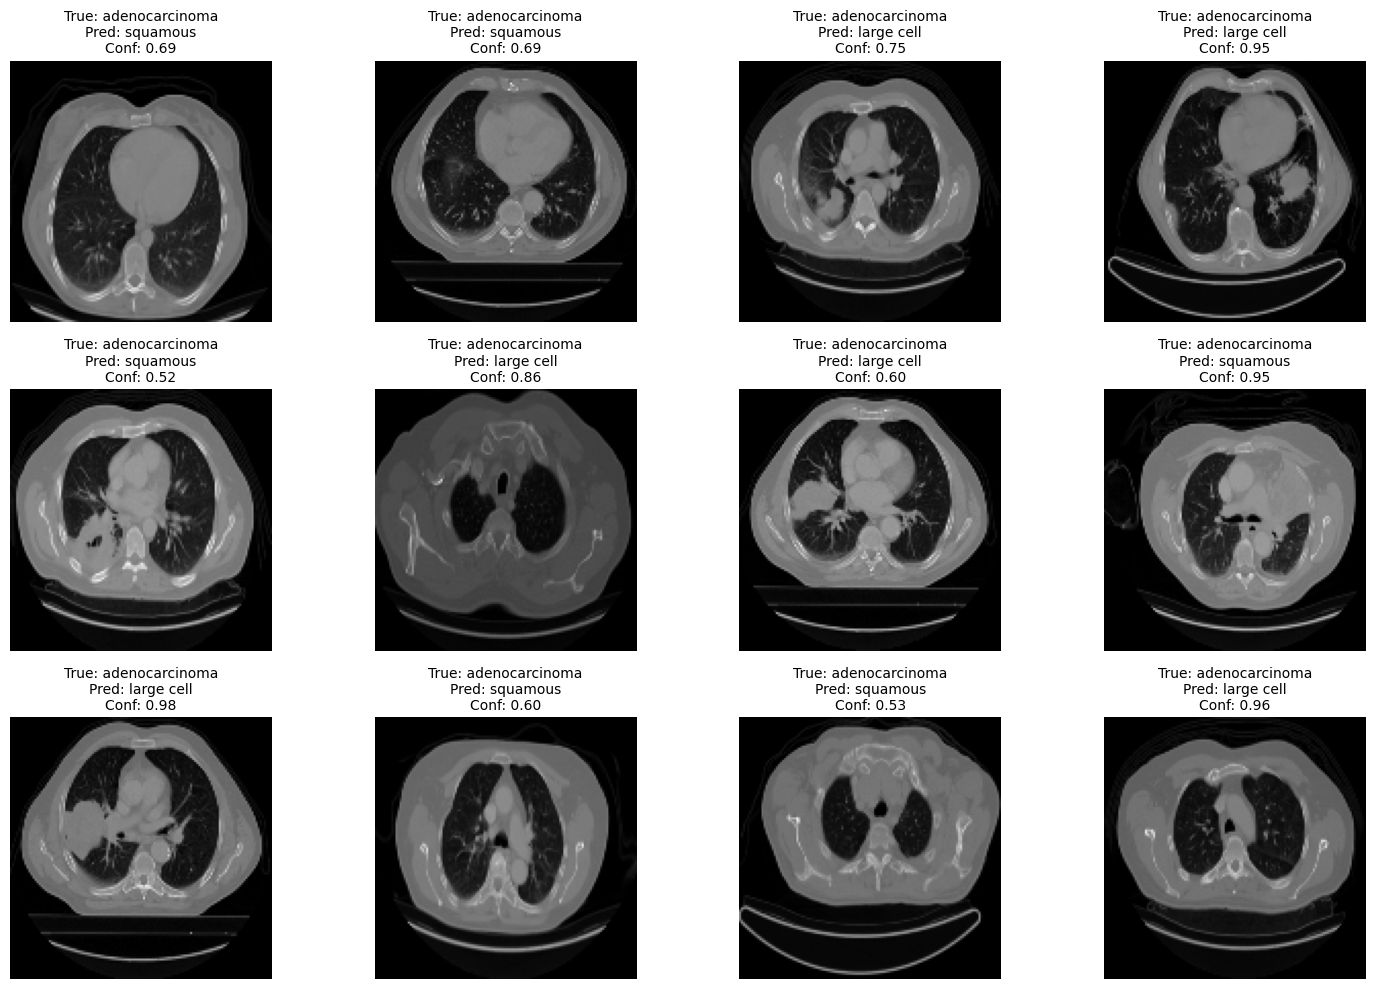

In [54]:
display_names = [
    "adenocarcinoma",
    "large cell",
    "normal",
    "squamous"
]

show_misclassified_images(
    final_model,
    final_test_data,
    display_names,
    num_images=12
)

### Eksempler på feilklassifiserte bilder

Figuren under viser eksempler fra testsettet der modellen predikerte feil klasse.
Dette ble brukt for å undersøke hvilke typer feil modellen gjorde, og om feilene
samsvarer med mønstrene i confusion matrix.

### Tolkning

Den frosne transfer learning-modellen ble valgt som final_model fordi den hadde best valideringsresultat. Fine-tuning ble brukt som et eksperiment, men ga svakere valideringsytelse.

In [55]:
final_model.save("model.keras")